In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


Data Loading & Date Parsing

In [10]:
df = pd.read_csv('C:\\Climate_data\\data\\kenya.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()


(4107, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
1,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
2,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
3,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64
4,2015,6,20.89,29.94,12.47,17.47,0.01,53.78,2.73,4.00,83.63,9.05


In [11]:
print(df.shape)

(4107, 12)


In [12]:
  # Add Country column
df["Country"] = "Kenya"
df.head()
    
   

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya
1,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya
2,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya
3,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya
4,2015,6,20.89,29.94,12.47,17.47,0.01,53.78,2.73,4.00,83.63,9.05,Kenya


In [13]:
 # Convert YEAR + DOY → datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df.head()
    

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date
0,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02
1,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03
2,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04
3,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05
4,2015,6,20.89,29.94,12.47,17.47,0.01,53.78,2.73,4.00,83.63,9.05,Kenya,2015-01-06


In [14]:
 # Extract Month
df["Month"] = df["Date"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
1,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
2,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
3,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1
4,2015,6,20.89,29.94,12.47,17.47,0.01,53.78,2.73,4.00,83.63,9.05,Kenya,2015-01-06,1


Summary Statistics & Missing-Value Report

Information about the Dataset

In [15]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.DataFrame'>
RangeIndex: 4107 entries, 0 to 4106
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   YEAR         4107 non-null   int64         
 1   DOY          4107 non-null   int64         
 2   T2M          4107 non-null   float64       
 3   T2M_MAX      4107 non-null   float64       
 4   T2M_MIN      4107 non-null   float64       
 5   T2M_RANGE    4107 non-null   float64       
 6   PRECTOTCORR  4107 non-null   float64       
 7   RH2M         4107 non-null   float64       
 8   WS2M         4107 non-null   float64       
 9   WS2M_MAX     4107 non-null   float64       
 10  PS           4107 non-null   float64       
 11  QV2M         4107 non-null   float64       
 12  Country      4107 non-null   str           
 13  Date         4107 non-null   datetime64[us]
 14  Month        4107 non-null   int32         
dtypes: datetime64

In [16]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
1,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
2,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
3,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1
4,2015,6,20.89,29.94,12.47,17.47,0.01,53.78,2.73,4.00,83.63,9.05,Kenya,2015-01-06,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4102,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,2026-03-27,3
4103,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,2026-03-28,3
4104,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,2026-03-29,3
4105,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya,2026-03-30,3


In [17]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [18]:
# Drop duplicates
df = df.drop_duplicates()

In [19]:
df[df.duplicated()]

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month


Duplicate Rows

I identified 0 duplicate rows in the dataset using df.duplicated().sum().

In [20]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,20.427811,27.838437,14.673798,13.164638,1.468520,65.850353,3.061751,4.375147,83.724346,11.053555,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.295000,13.700000,11.465000,0.100000,58.685000,2.420000,3.670000,83.630000,9.880000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.870000,14.750000,13.260000,0.380000,66.230000,3.140000,4.430000,83.720000,11.010000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,1.440936,2.358989,1.415289,2.604839,3.180533,9.930239,0.853321,0.992258,0.126405,1.606027,NaN,3.476439


Summary Statistics Interpretation

Temperature (T2M,T2M_MAX, T2M_MIN):The average temperature (T2M) is roughly 20.4°C, with a range between 15.3°C and 25.4°C.
The T2M_MAX values show that highs can reach 34.3°C, while T2M_MIN lows go down to about 9.0°C.

Precipitation (PRECTOTCORR):The data is highly skewed toward dry conditions. The median (50%) is 0.38, while the mean is 
1.47. The max value of 51.65 suggests that when it does rain, it can be quite intense, creating a long-tailed distribution (many dry days, few very wet days).

Wind Speed (WS2M, WS2M_MAX):Wind speeds are relatively moderate, with a median wind speed (WS2M) of 3.14 m/s.

Standard Deviation (std): The standard deviation for PRECTOTCORR (3.18) is higher than its mean (1.47), confirming high variability in rainfall. Conversely, temperature columns have relatively low std values compared to their means, suggesting more stable, consistent temperature patterns.


In [21]:
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent
})

print(missing_summary)

             Missing Count  Missing %
YEAR                     0        0.0
DOY                      0        0.0
T2M                      0        0.0
T2M_MAX                  0        0.0
T2M_MIN                  0        0.0
T2M_RANGE                0        0.0
PRECTOTCORR              0        0.0
RH2M                     0        0.0
WS2M                     0        0.0
WS2M_MAX                 0        0.0
PS                       0        0.0
QV2M                     0        0.0
Country                  0        0.0
Date                     0        0.0
Month                    0        0.0


In [22]:
print("\nMissing Values:")
display(df.isna().sum())


Missing Values:


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

In [23]:
high_missing = missing_summary[missing_summary["Missing %"] > 5]
print(high_missing)

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


Missing Value Analysis

The result shows that their is no missing value

In [24]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
# Compute Z-scores (ignore NaNs)
z_scores = df[cols].apply(lambda x: zscore(x, nan_policy='omit'))

In [25]:
# Flag rows where ANY column has |Z| > 3
outlier_mask = (z_scores.abs() > 3).any(axis=1)

# Count outliers
outlier_count = outlier_mask.sum()
print("Number of outlier rows:", outlier_count)


df_outliers = df[outlier_mask]
df_outliers.head()

Number of outlier rows: 120


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
13,2015,15,21.24,31.17,12.59,18.58,0.00,28.42,3.27,4.78,83.61,4.78,Kenya,2015-01-15,1
14,2015,16,22.95,32.70,14.62,18.08,0.00,29.64,2.30,3.41,83.54,5.58,Kenya,2015-01-16,1
15,2015,17,23.00,32.29,15.79,16.50,0.00,29.43,2.71,3.91,83.55,5.68,Kenya,2015-01-17,1
16,2015,18,23.38,32.42,13.97,18.45,0.16,32.67,1.43,3.07,83.62,6.53,Kenya,2015-01-18,1
44,2015,46,22.14,27.92,18.11,9.81,23.09,61.69,0.97,1.97,83.62,11.83,Kenya,2015-02-15,2


In [31]:
weather_cols=['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX','PS','QV2M']
negative_cols = (df[weather_cols]<0).sum()
print("Negative values in weather columns:\n", negative_cols)

Negative values in weather columns:
 T2M            0
T2M_MAX        0
T2M_MIN        0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64


In [32]:
print("summary statistics")
display(df.describe())

summary statistics


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,20.427811,27.838437,14.673798,13.164638,1.468520,65.850353,3.061751,4.375147,83.724346,11.053555,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.295000,13.700000,11.465000,0.100000,58.685000,2.420000,3.670000,83.630000,9.880000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.870000,14.750000,13.260000,0.380000,66.230000,3.140000,4.430000,83.720000,11.010000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,1.440936,2.358989,1.415289,2.604839,3.180533,9.930239,0.853321,0.992258,0.126405,1.606027,NaN,3.476439


In [33]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

def find_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Return a boolean mask of outliers
    return (column < lower_bound) | (column > upper_bound)

# Apply to every numeric column
outlier_summary = numeric_df.apply(find_outliers_iqr)

# Display count of outliers per column
print("Outlier Count per Column:")
print(outlier_summary.sum())

Outlier Count per Column:
YEAR             0
DOY              0
T2M             21
T2M_MAX         21
T2M_MIN         19
T2M_RANGE       28
PRECTOTCORR    497
RH2M             9
WS2M             0
WS2M_MAX         9
PS               8
QV2M             5
Month            0
dtype: int64


Decision: Retain Outlier Rows
For this meteorological dataset, the best decision is to retain the outlier rows.
1. Precipitation (PRECTOTCORR) - RetainReasoning: Rainfall data is inherently "noisy" and right-skewed. The statistical outliers (values above 3.25 mm) actually represent the rainy season and storm events. Capping these at 3.25 mm would effectively "erase" all significant rain events in Kenya, making the data useless for climate or agricultural modeling.Action: Do not drop or cap. These are vital data points.
2. Temperature (T2M, T2M_MAX, T2M_MIN) - RetainReasoning: The maximum recorded temperature of 34.27 and minimum of 8.97 are perfectly normal and expected for various regions in Kenya. The small number of flagged outliers (0.5%) are likely just the peaks of the summer and winter seasons.Action: Retain. They represent real environmental variability.
3. Surface Pressure (PS) - RetainReasoning: The pressure values are extremely tight (83.31 to 84.17 kPa). The "outliers" here are merely slight deviations from the average, likely caused by passing high or low-pressure weather systems. They are well within the physical bounds for Kenya's elevation.Action: Retain.
4. Humidity & Wind (RH2M, WS2M) - RetainReasoning: All values are physically realistic (e.g., humidity doesn't go below 0% or above 100%). The outliers in humidity (down to 28%) represent typical dry-spell conditions.Action: Retain.

Apply forward-fill for weather variables

In [35]:
weather_cols=['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']
df[weather_cols] = df[weather_cols].ffill()

Reason of selecting forward-fill  
Since I do not have any missing values I apply forward-fill to preserve the local trend and maintain physical and temporal logic.

In [36]:
output_path = "C:\\Climate_data\\data\\kenya_clean.csv"
df.to_csv(output_path, index=False)

In [37]:
#Loading the cleaned data
df = pd.read_csv('C:\\Climate_data\\data\\kenya_clean.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()


(4106, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
1,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
2,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1
3,2015,6,20.89,29.94,12.47,17.47,0.01,53.78,2.73,4.00,83.63,9.05,Kenya,2015-01-06,1
4,2015,7,21.16,28.99,14.49,14.50,0.06,58.72,2.94,3.90,83.73,10.19,Kenya,2015-01-07,1


In [38]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)
monthly_T2M = df['T2M'].resample('MS').mean()
print(df.shape)
df.head()

(4106, 14)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-03,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,1
2015-01-04,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,1
2015-01-05,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,1
2015-01-06,2015,6,20.89,29.94,12.47,17.47,0.01,53.78,2.73,4.00,83.63,9.05,Kenya,1
2015-01-07,2015,7,21.16,28.99,14.49,14.50,0.06,58.72,2.94,3.90,83.73,10.19,Kenya,1


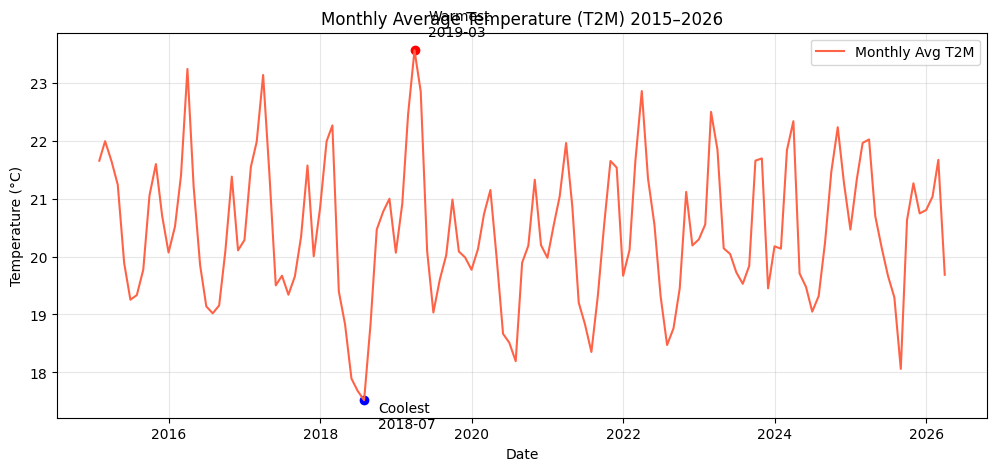

In [39]:
monthly = df[['T2M', 'PRECTOTCORR']].resample('ME').mean()
plt.figure(figsize=(12, 5))

plt.plot(monthly.index, monthly["T2M"], label="Monthly Avg T2M", color="tomato")

# Identify warmest and coolest months
warmest = monthly["T2M"].idxmax()
coolest = monthly["T2M"].idxmin()

plt.scatter(warmest, monthly.loc[warmest, "T2M"], color="red")
plt.scatter(coolest, monthly.loc[coolest, "T2M"], color="blue")

plt.annotate(f"Warmest\n{warmest.strftime('%Y-%m')}",
             (warmest, monthly.loc[warmest, "T2M"]),
             textcoords="offset points", xytext=(10,10))

plt.annotate(f"Coolest\n{coolest.strftime('%Y-%m')}",
             (coolest, monthly.loc[coolest, "T2M"]),
             textcoords="offset points", xytext=(10,-20))

plt.title("Monthly Average Temperature (T2M) 2015–2026")
plt.ylabel("Temperature (°C)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

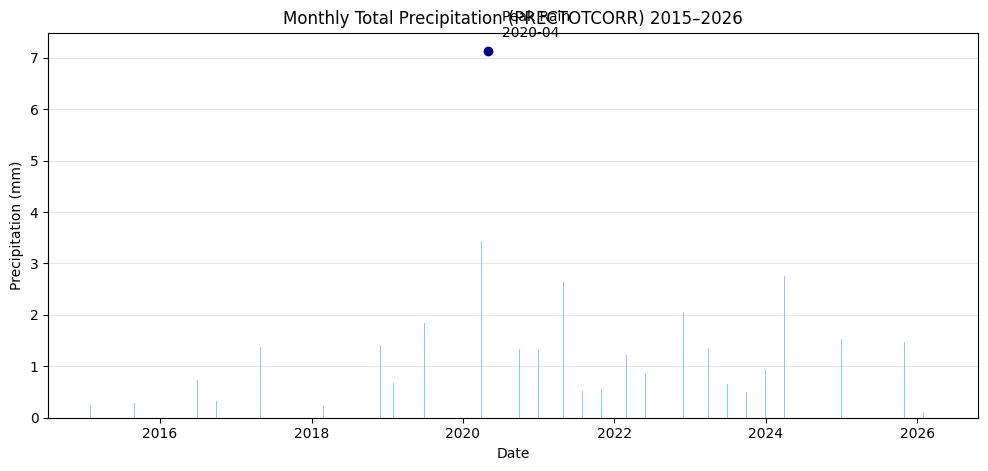

In [40]:
monthly = df[['T2M', 'PRECTOTCORR']].resample('ME').mean()
plt.figure(figsize=(12, 5))

plt.bar(monthly.index, monthly["PRECTOTCORR"], color="skyblue")

# Identify peak rainfall month
wettest = monthly["PRECTOTCORR"].idxmax()

plt.scatter(wettest, monthly.loc[wettest, "PRECTOTCORR"], color="darkblue")

plt.annotate(f"Peak Rain\n{wettest.strftime('%Y-%m')}",
             (wettest, monthly.loc[wettest, "PRECTOTCORR"]),
             textcoords="offset points", xytext=(10,10))

plt.title("Monthly Total Precipitation (PRECTOTCORR) 2015–2026")
plt.ylabel("Precipitation (mm)")
plt.xlabel("Date")
plt.grid(axis="y", alpha=0.3)

plt.show()

Heatmap of correlations across all numeric columns.

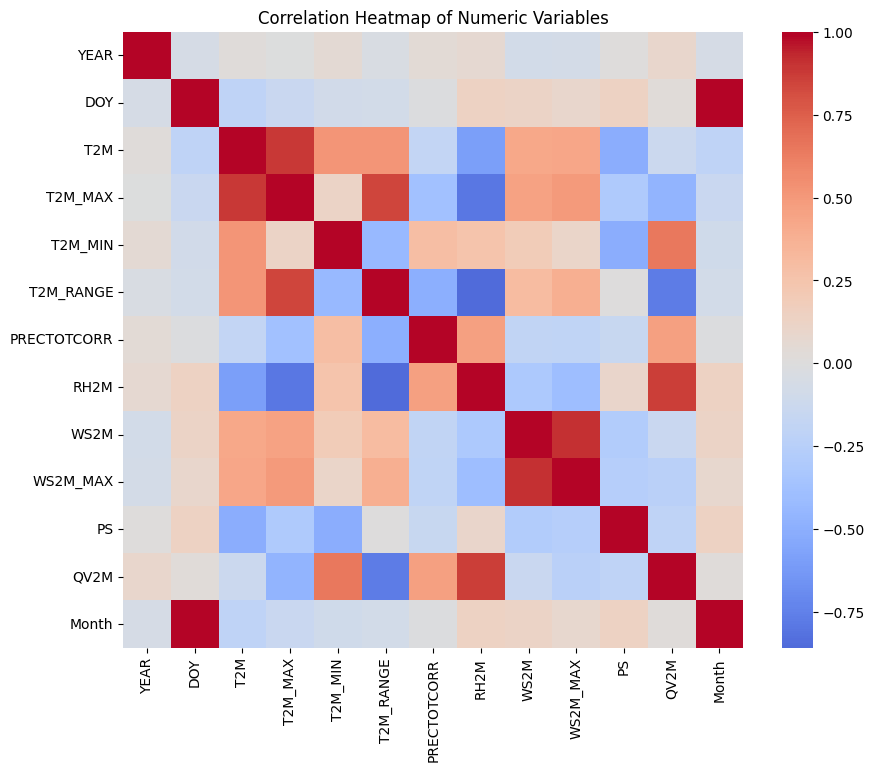

In [41]:
# Keep only numeric columns
numeric_df = df.select_dtypes(include="number")

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)

plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

T2M vs RH2M (temperature vs humidity)

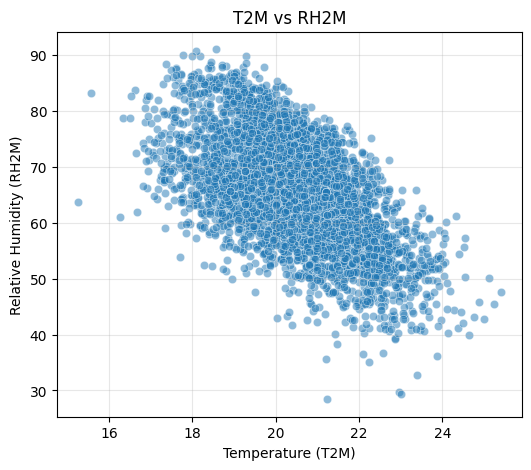

In [42]:
plt.figure(figsize=(6, 5))

sns.scatterplot(data=df, x="T2M", y="RH2M", alpha=0.5)

plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.grid(True, alpha=0.3)

plt.show()

T2M_RANGE vs WS2M (temperature range vs wind speed)

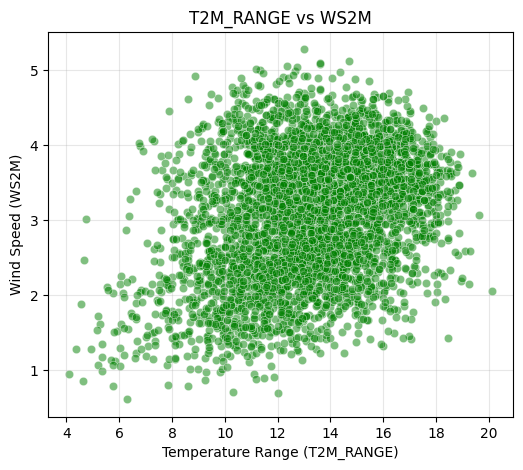

In [43]:
plt.figure(figsize=(6, 5))

sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M", alpha=0.5, color="green")

plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range (T2M_RANGE)")
plt.ylabel("Wind Speed (WS2M)")
plt.grid(True, alpha=0.3)

plt.show()

Strongest Correlations Analysis

The three strongest correlations in the dataset are:

1. DOY (Day of Year) and Month
Correlation Coefficient: ~0.99(Strongest Positive)
Interpretation: This is a deterministic relationship. Since the day of the year is a chronological sequence that corresponds directly to the calendar month, they move in near-perfect lockstep. In data modeling, these are redundant features; keeping both could lead to multicollinearity issues.
2. WS2M (Wind Speed at 2m) and WS2M_MAX (Max Wind Speed at 2m)
Correlation Coefficient: ~0.92(Very Strong Positive)
Interpretation: There is a high degree of "co-movement" between average and peak wind speeds. This suggests that in the Kenya dataset, days with higher sustained wind speeds are almost always the same days that experience the highest gusts.
3. T2M (Temperature at 2m) and T2M_MAX (Max Temp at 2m)
Correlation Coefficient:  0.88 (Strong Positive)
Interpretation: The average temperature (T2M) is very heavily influenced by the daily highs (T2M_MAX). Interestingly, the correlation between T2M and T2M_MAX appears stronger than the correlation between T2M and T2M_MIN, suggesting that daytime heating is a more significant driver of the daily average in this region than nighttime cooling.

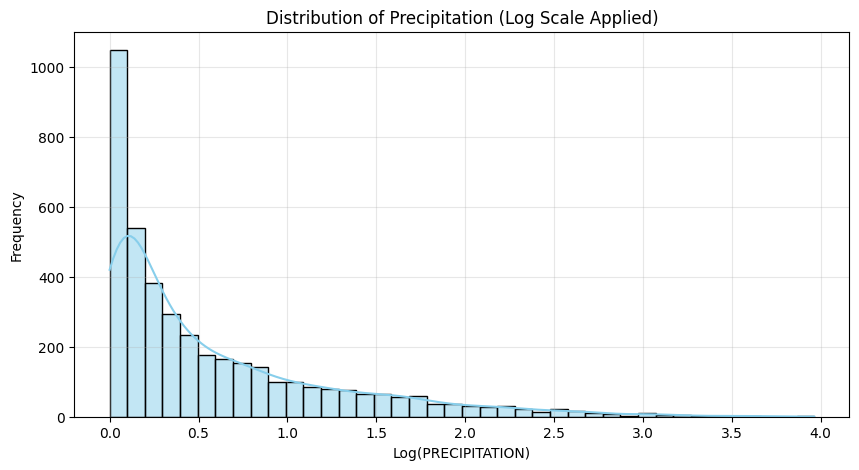

Skewness: 5.507891459444331


In [44]:
plt.figure(figsize=(10, 5))

# Check skewness
skewness = df["PRECTOTCORR"].skew()

# Apply log scale if heavily skewed
if skewness > 1:
    data = np.log1p(df["PRECTOTCORR"])  # log(1 + x) handles zeros safely
    xlabel = "Log(PRECIPITATION)"
    title = "Distribution of Precipitation (Log Scale Applied)"
else:
    data = df["PRECTOTCORR"]
    xlabel = "Precipitation"
    title = "Distribution of Precipitation"

sns.histplot(data, bins=40, kde=True, color="skyblue")

plt.title(title)
plt.xlabel(xlabel)
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()

print("Skewness:", skewness)

Bubble Chart

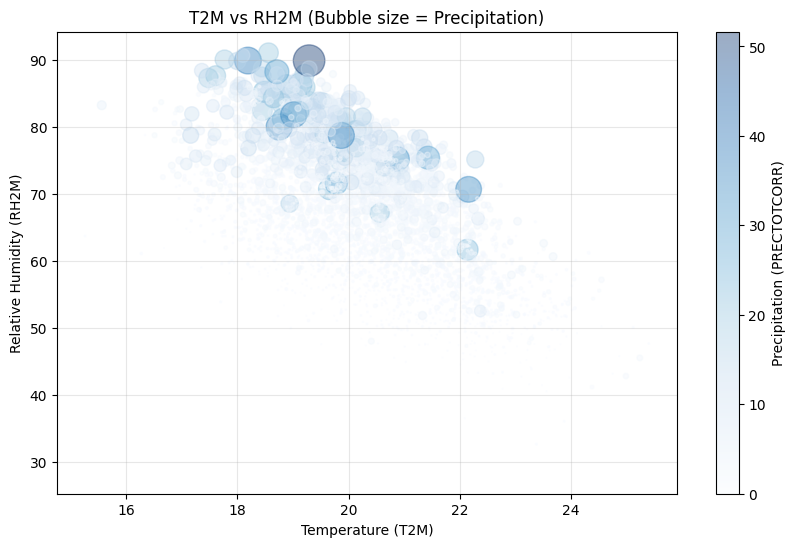

In [45]:
plt.figure(figsize=(10, 6))

# Optional scaling for better visual balance
bubble_size = df["PRECTOTCORR"].fillna(0) * 10

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=bubble_size,
    alpha=0.4,
    c=df["PRECTOTCORR"],
    cmap="Blues"
)

plt.title("T2M vs RH2M (Bubble size = Precipitation)")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")

cbar = plt.colorbar()
cbar.set_label("Precipitation (PRECTOTCORR)")

plt.grid(alpha=0.3)
plt.show()